# Cross-Province Model Comparison

Compares TFT and XGBoost solar forecast performance across three Spanish provinces:
- **Cáceres** (Extremadura) — inland, semi-arid, 2,463 MWp top-8
- **Cádiz** (Andalucía) — coastal lowland, 715 MWp top-8
- **Zaragoza** (Aragón) — Ebro valley, 462 MWp top-8

For each province, five model variants were trained:

**TFT (Temporal Fusion Transformer)** — sequence model with 168h encoder:
1. **Standard** — weather as observed (encoder-only)
2. **NWP** — Open-Meteo forecasts as known-future (encoder + decoder)
3. **Perfect forecast** — ERA5 reanalysis as known-future (performance ceiling)

**XGBoost** — tabular baseline (no sequences, current-timestep features only):
4. **Standard** — same 17 features as TFT Standard
5. **NWP** — same 24 features as TFT NWP

**Key questions:**
- Does TFT's temporal modelling add value over a simpler tabular baseline?
- Does the NWP improvement pattern hold across provinces and model types?

In [8]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Province Configuration

In [9]:
# Province definitions
PROVINCES = {
    'Cáceres': {
        'dir': 'caceres_analysis',
        'capacity_mwp': 2463.01,
        'n_plants': 8,
        'region': 'Extremadura',
        'climate': 'Inland semi-arid',
    },
    'Cádiz': {
        'dir': 'cadiz_analysis',
        'capacity_mwp': 714.60,
        'n_plants': 8,
        'region': 'Andalucía',
        'climate': 'Coastal lowland',
    },
    'Zaragoza': {
        'dir': 'zaragoza_analysis',
        'capacity_mwp': 462.40,
        'n_plants': 8,
        'region': 'Aragón',
        'climate': 'Ebro valley continental',
    },
}

# Navigate to project root
PROJECT_ROOT = os.getcwd()
# If running from a subdirectory, try to find the project root
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'caceres_analysis')):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

print(f'Project root: {PROJECT_ROOT}')
for name, info in PROVINCES.items():
    exists = os.path.isdir(os.path.join(PROJECT_ROOT, info['dir']))
    print(f"  {name:12s}  {info['dir']:25s}  exists={exists}")

Project root: /home/tzf/bachelor/MLVU/project/ML-solar-forecast
  Cáceres       caceres_analysis           exists=True
  Cádiz         cadiz_analysis             exists=True
  Zaragoza      zaragoza_analysis          exists=True


## 2. Load Results

In [10]:
def load_metrics(province_dir, json_paths, metrics_key, fallback_key):
    """Load metrics from a JSON results file. Tries multiple paths.
    Returns dict with R2, RMSE_MWh, MAE_MWh or None."""
    if isinstance(json_paths, str):
        json_paths = [json_paths]
    for json_path in json_paths:
        full_path = os.path.join(PROJECT_ROOT, province_dir, json_path)
        if os.path.exists(full_path):
            with open(full_path) as f:
                data = json.load(f)
            metrics = data.get(metrics_key) or data.get(fallback_key)
            if metrics:
                print(f'  Found: {province_dir}/{json_path} -> {list(metrics.keys())}')
                return metrics
    return None


def get_peak_generation(province_dir, province_name):
    """Get peak hourly generation from the assembled dataset (= ESIOS total provincial PV)."""
    csv_name = province_name.lower() + '_assembled_dataset.csv'
    csv_path = os.path.join(PROJECT_ROOT, province_dir, 'data', csv_name)
    df = pd.read_csv(csv_path, usecols=['pv_generation_gwh'])  # column name is gwh but unit is MWh
    return df['pv_generation_gwh'].max()


# Model variants and where their results are stored
# Multiple candidate paths per model to handle naming differences across provinces
MODELS = {
    'TFT Standard': {
        'json': ['models/hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'TFT NWP': {
        'json': [
            'models/nwp_forecast/nwp_hp_study_results.json',  # Cádiz/Zaragoza naming
            'models/nwp_forecast/hp_study_results.json',       # alternative naming
        ],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'TFT Perfect Forecast': {
        'json': ['models/perfect_forecast/hp_study_results_pf.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'XGBoost Standard': {
        'json': ['models/xgboost_hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
    'XGBoost NWP': {
        'json': ['models/xgboost_nwp_hp_study_results.json'],
        'metrics_key': 'test_metrics_mwh',
        'fallback_key': 'val_metrics_mwh',
    },
}

# Collect all results + compute peak generation per province for proper nRMSE
rows = []
for prov_name, prov_info in PROVINCES.items():
    print(f'\n{prov_name}:')
    
    # Get peak generation from ESIOS data (total provincial PV, not just top-8)
    peak_gen = get_peak_generation(prov_info['dir'], prov_name.replace('á', 'a').replace('é', 'e'))
    prov_info['peak_gen_mwh'] = peak_gen
    print(f'  Peak ESIOS generation: {peak_gen:.1f} MWh  (top-8 capacity: {prov_info["capacity_mwp"]:.0f} MWp, ratio: {peak_gen/prov_info["capacity_mwp"]:.2f}x)')
    
    for model_name, model_info in MODELS.items():
        metrics = load_metrics(
            prov_info['dir'],
            model_info['json'],
            model_info['metrics_key'],
            model_info['fallback_key'],
        )
        if metrics:
            rows.append({
                'Province': prov_name,
                'Model': model_name,
                'R2': metrics.get('R2'),
                'RMSE_MWh': metrics.get('RMSE_MWh'),
                'MAE_MWh': metrics.get('MAE_MWh'),
                'Capacity_MWp': prov_info['capacity_mwp'],
                'Peak_Gen_MWh': peak_gen,
            })
        else:
            print(f'  MISSING: {model_name}')
            rows.append({
                'Province': prov_name,
                'Model': model_name,
                'R2': None, 'RMSE_MWh': None, 'MAE_MWh': None,
                'Capacity_MWp': prov_info['capacity_mwp'],
                'Peak_Gen_MWh': peak_gen,
            })

results = pd.DataFrame(rows)

# nRMSE normalized by peak observed generation (fair cross-province comparison)
# This accounts for the fact that ESIOS covers ALL provincial PV, not just the top-8 plants
results['nRMSE_pct'] = (results['RMSE_MWh'] / results['Peak_Gen_MWh'] * 100).round(2)

n_found = results['R2'].notna().sum()
n_total = len(results)
print(f'\nLoaded {n_found}/{n_total} model results ({n_total - n_found} missing)')
results


Cáceres:
  Peak ESIOS generation: 2959.8 MWh  (top-8 capacity: 2463 MWp, ratio: 1.20x)
  Found: caceres_analysis/models/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres_analysis/models/nwp_forecast/nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres_analysis/models/perfect_forecast/hp_study_results_pf.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres_analysis/models/xgboost_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: caceres_analysis/models/xgboost_nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']

Cádiz:
  Peak ESIOS generation: 1480.6 MWh  (top-8 capacity: 715 MWp, ratio: 2.07x)
  Found: cadiz_analysis/models/hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz_analysis/models/nwp_forecast/nwp_hp_study_results.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz_analysis/models/perfect_forecast/hp_study_results_pf.json -> ['MAE_MWh', 'RMSE_MWh', 'R2']
  Found: cadiz_analysis/models/xgbo

,Province,Model,R2,RMSE_MWh,MAE_MWh,Capacity_MWp,Peak_Gen_MWh,nRMSE_pct
0,Cáceres,TFT Standard,0.839099,334.417236,179.965820,2463.01,2959.799,11.30
1,Cáceres,TFT NWP,0.885869,281.650238,151.946060,2463.01,2959.799,9.52
2,Cáceres,TFT Perfect Forecast,0.888624,278.230865,145.504028,2463.01,2959.799,9.40
3,Cáceres,XGBoost Standard,0.890859,235.777775,119.480463,2463.01,2959.799,7.97
4,Cáceres,XGBoost NWP,0.895907,230.260511,117.234453,2463.01,2959.799,7.78
5,Cádiz,TFT Standard,0.696950,218.379471,124.684715,714.60,1480.592,14.75
6,Cádiz,TFT NWP,0.761473,193.741882,108.499535,714.60,1480.592,13.09
7,Cádiz,TFT Perfect Forecast,0.704599,215.605865,122.561928,714.60,1480.592,14.56
8,Cádiz,XGBoost Standard,0.747556,228.866767,132.429416,714.60,1480.592,15.46
9,Cádiz,XGBoost NWP,0.757992,224.086352,128.974951,714.60,1480.592,15.13


## 3. Three-Way Comparison per Province

In [11]:
for prov_name in PROVINCES:
    prov_results = results[results['Province'] == prov_name].copy()
    cap = PROVINCES[prov_name]['capacity_mwp']
    climate = PROVINCES[prov_name]['climate']
    
    print('=' * 75)
    print(f'FIVE-WAY COMPARISON — {prov_name} ({climate}, {cap:.0f} MWp)')
    print('=' * 75)
    print(f'{"Model":35s} {"RMSE (MWh)":>12s} {"MAE (MWh)":>11s} {"R²":>8s} {"nRMSE %":>8s}')
    print('-' * 75)
    
    for _, row in prov_results.iterrows():
        if row['R2'] is not None and not pd.isna(row['R2']):
            print(f'{row["Model"]:35s} {row["RMSE_MWh"]:>12.2f} {row["MAE_MWh"]:>11.2f} {row["R2"]:>8.4f} {row["nRMSE_pct"]:>7.2f}%')
        else:
            print(f'{row["Model"]:35s} {"—":>12s} {"—":>11s} {"—":>8s} {"—":>8s}')
    
    # Extract R² per model
    def get_r2(model_name):
        v = prov_results.loc[prov_results['Model'] == model_name, 'R2'].values
        return v[0] if len(v) and pd.notna(v[0]) else None

    tft_std = get_r2('TFT Standard')
    tft_nwp = get_r2('TFT NWP')
    tft_pf  = get_r2('TFT Perfect Forecast')
    xgb_std = get_r2('XGBoost Standard')
    xgb_nwp = get_r2('XGBoost NWP')

    print()
    # TFT inter-model deltas
    if tft_std is not None and tft_nwp is not None:
        print(f'  TFT: NWP vs Standard:         ΔR² = {tft_nwp - tft_std:+.4f}')
    if tft_std is not None and tft_pf is not None:
        print(f'  TFT: Perfect vs Standard:     ΔR² = {tft_pf - tft_std:+.4f}')

    # XGBoost inter-model deltas
    if xgb_std is not None and xgb_nwp is not None:
        print(f'  XGB: NWP vs Standard:         ΔR² = {xgb_nwp - xgb_std:+.4f}')

    # TFT vs XGBoost (same feature set)
    if tft_std is not None and xgb_std is not None:
        print(f'  TFT Standard vs XGB Standard: ΔR² = {tft_std - xgb_std:+.4f}')
    if tft_nwp is not None and xgb_nwp is not None:
        print(f'  TFT NWP vs XGB NWP:           ΔR² = {tft_nwp - xgb_nwp:+.4f}')
    print()

FIVE-WAY COMPARISON — Cáceres (Inland semi-arid, 2463 MWp)
Model                                 RMSE (MWh)   MAE (MWh)       R²  nRMSE %
---------------------------------------------------------------------------
TFT Standard                              334.42      179.97   0.8391   11.30%
TFT NWP                                   281.65      151.95   0.8859    9.52%
TFT Perfect Forecast                      278.23      145.50   0.8886    9.40%
XGBoost Standard                          235.78      119.48   0.8909    7.97%
XGBoost NWP                               230.26      117.23   0.8959    7.78%

  TFT: NWP vs Standard:         ΔR² = +0.0468
  TFT: Perfect vs Standard:     ΔR² = +0.0495
  XGB: NWP vs Standard:         ΔR² = +0.0050
  TFT Standard vs XGB Standard: ΔR² = -0.0518
  TFT NWP vs XGB NWP:           ΔR² = -0.0100

FIVE-WAY COMPARISON — Cádiz (Coastal lowland, 715 MWp)
Model                                 RMSE (MWh)   MAE (MWh)       R²  nRMSE %
-------------------------

## 4. Cross-Province Pivot Table

In [12]:
# Pivot: provinces as rows, models as columns
available = results.dropna(subset=['R2'])

if len(available) > 0:
    pivot_r2 = available.pivot(index='Province', columns='Model', values='R2')
    pivot_rmse = available.pivot(index='Province', columns='Model', values='RMSE_MWh')
    pivot_nrmse = available.pivot(index='Province', columns='Model', values='nRMSE_pct')

    # Reorder columns: XGBoost first, then TFT
    col_order = ['XGBoost Standard', 'XGBoost NWP', 'TFT Standard', 'TFT NWP', 'TFT Perfect Forecast']
    col_order = [c for c in col_order if c in pivot_r2.columns]

    print('=== R² by Province and Model ===')
    print(pivot_r2[col_order].round(4).to_string())

    print('\n=== RMSE (MWh) by Province and Model ===')
    print(pivot_rmse[col_order].round(2).to_string())

    print('\n=== nRMSE (% of peak observed generation) by Province and Model ===')
    print(pivot_nrmse[col_order].round(2).to_string())
else:
    print('No results available yet. Run the training/evaluation pipelines first.')

=== R² by Province and Model ===
Model     XGBoost Standard  XGBoost NWP  TFT Standard  TFT NWP  TFT Perfect Forecast
Province                                                                            
Cáceres             0.8909       0.8959        0.8391   0.8859                0.8886
Cádiz               0.7476       0.7580        0.6969   0.7615                0.7046
Zaragoza            0.8810       0.8930        0.7825   0.8640                0.8932

=== RMSE (MWh) by Province and Model ===
Model     XGBoost Standard  XGBoost NWP  TFT Standard  TFT NWP  TFT Perfect Forecast
Province                                                                            
Cáceres             235.78       230.26        334.42   281.65                278.23
Cádiz               228.87       224.09        218.38   193.74                215.61
Zaragoza            172.62       163.66        214.52   169.59                163.36

=== nRMSE (% of peak observed generation) by Province and Model ===
Model 

## 5. Visualizations

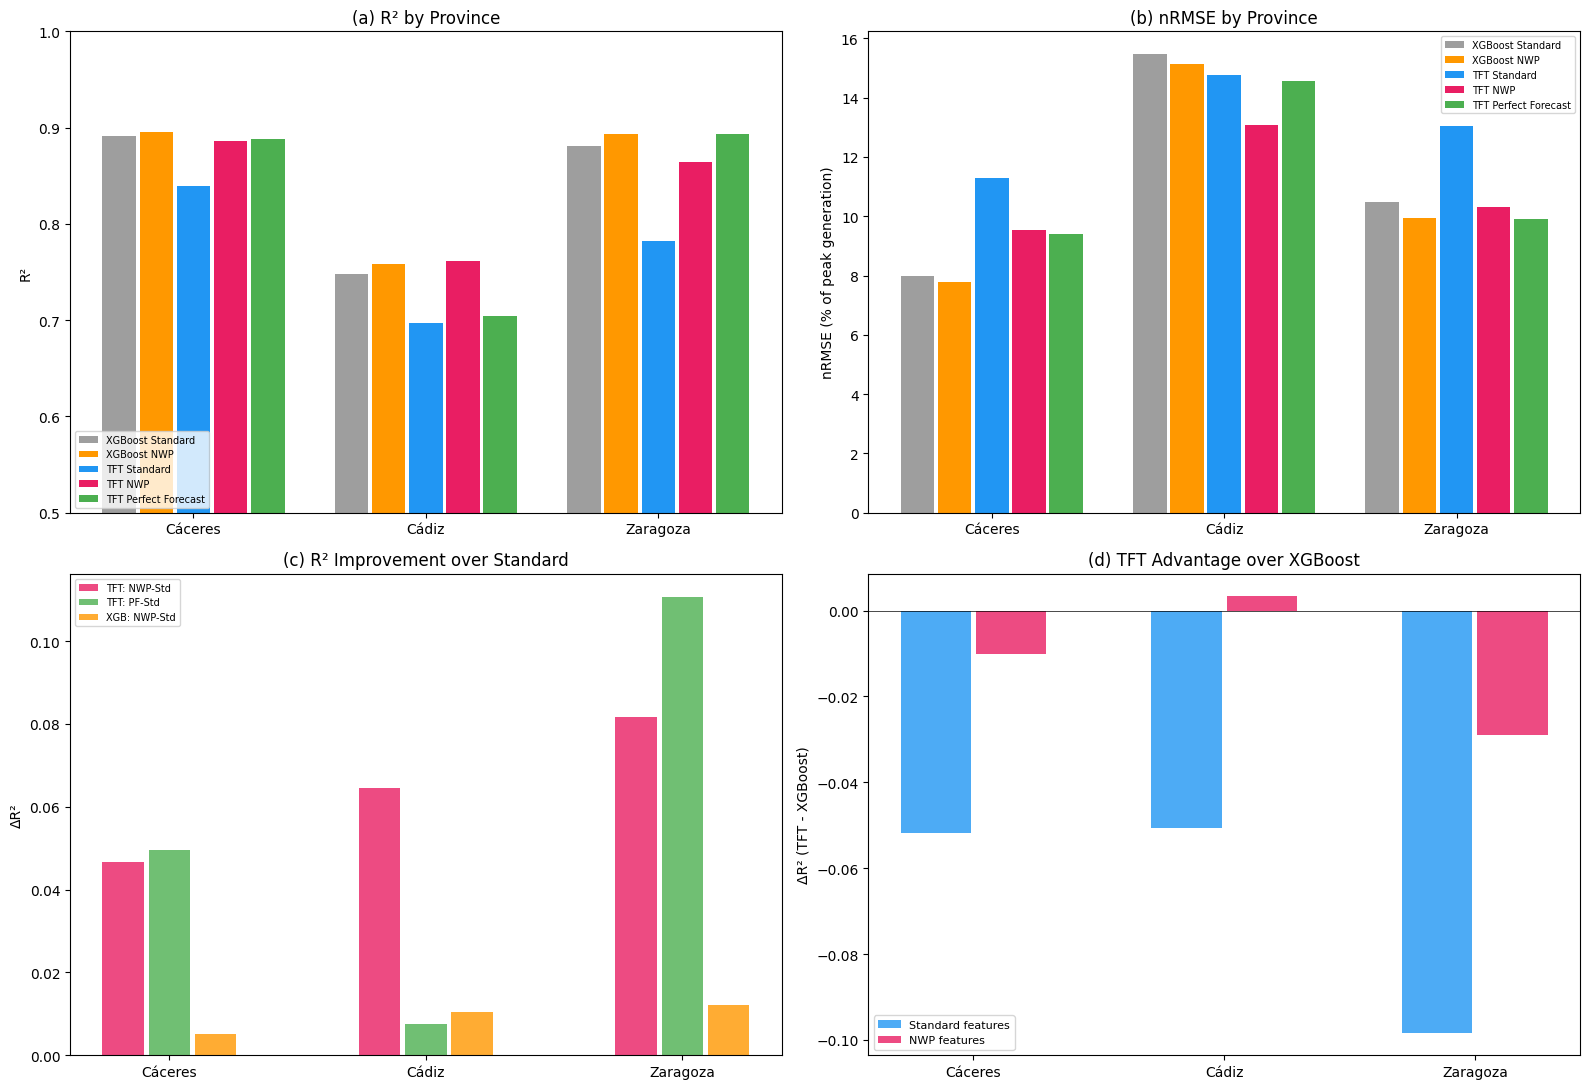

In [13]:
available = results.dropna(subset=['R2'])

if len(available) >= 3:  # Need at least one province with results
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    col_order = ['XGBoost Standard', 'XGBoost NWP', 'TFT Standard', 'TFT NWP', 'TFT Perfect Forecast']
    col_order = [c for c in col_order if c in available['Model'].values]
    colors = ['#9E9E9E', '#FF9800', '#2196F3', '#E91E63', '#4CAF50'][:len(col_order)]
    prov_names = list(PROVINCES.keys())
    n_models = len(col_order)
    bar_width = 0.8 / n_models

    # (a) R² comparison
    for i, model in enumerate(col_order):
        vals = []
        for prov in prov_names:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals.append(row['R2'].values[0] if len(row) > 0 else 0)
        x = np.arange(len(prov_names)) + i * bar_width
        axes[0, 0].bar(x, vals, bar_width * 0.9, label=model, color=colors[i])
    axes[0, 0].set_xticks(np.arange(len(prov_names)) + bar_width * (n_models - 1) / 2)
    axes[0, 0].set_xticklabels(prov_names)
    axes[0, 0].set_ylabel('R²')
    axes[0, 0].set_title('(a) R² by Province')
    axes[0, 0].legend(fontsize=7, loc='lower left')
    axes[0, 0].set_ylim(0.5, 1.0)

    # (b) nRMSE comparison
    for i, model in enumerate(col_order):
        vals = []
        for prov in prov_names:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals.append(row['nRMSE_pct'].values[0] if len(row) > 0 else 0)
        x = np.arange(len(prov_names)) + i * bar_width
        axes[0, 1].bar(x, vals, bar_width * 0.9, label=model, color=colors[i])
    axes[0, 1].set_xticks(np.arange(len(prov_names)) + bar_width * (n_models - 1) / 2)
    axes[0, 1].set_xticklabels(prov_names)
    axes[0, 1].set_ylabel('nRMSE (% of peak generation)')
    axes[0, 1].set_title('(b) nRMSE by Province')
    axes[0, 1].legend(fontsize=7)

    # (c) ΔR² — NWP improvement for both model types
    x = np.arange(len(prov_names))
    bar_w = 0.18
    delta_items = [
        ('TFT: NWP-Std', 'TFT Standard', 'TFT NWP', '#E91E63'),
        ('TFT: PF-Std', 'TFT Standard', 'TFT Perfect Forecast', '#4CAF50'),
        ('XGB: NWP-Std', 'XGBoost Standard', 'XGBoost NWP', '#FF9800'),
    ]
    for j, (label, base, improved, color) in enumerate(delta_items):
        deltas = []
        for prov in prov_names:
            base_row = available[(available['Province'] == prov) & (available['Model'] == base)]
            imp_row  = available[(available['Province'] == prov) & (available['Model'] == improved)]
            if len(base_row) and len(imp_row):
                deltas.append(imp_row['R2'].values[0] - base_row['R2'].values[0])
            else:
                deltas.append(0)
        axes[1, 0].bar(x + j * bar_w - bar_w, deltas, bar_w * 0.9, label=label, color=color, alpha=0.8)
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(prov_names)
    axes[1, 0].set_ylabel('ΔR²')
    axes[1, 0].set_title('(c) R² Improvement over Standard')
    axes[1, 0].legend(fontsize=7)
    axes[1, 0].axhline(0, color='black', lw=0.5)

    # (d) TFT vs XGBoost (same feature set)
    delta_tft_xgb = [
        ('Standard features', 'XGBoost Standard', 'TFT Standard', '#2196F3'),
        ('NWP features', 'XGBoost NWP', 'TFT NWP', '#E91E63'),
    ]
    for j, (label, xgb_model, tft_model, color) in enumerate(delta_tft_xgb):
        deltas = []
        for prov in prov_names:
            xgb_row = available[(available['Province'] == prov) & (available['Model'] == xgb_model)]
            tft_row = available[(available['Province'] == prov) & (available['Model'] == tft_model)]
            if len(xgb_row) and len(tft_row):
                deltas.append(tft_row['R2'].values[0] - xgb_row['R2'].values[0])
            else:
                deltas.append(0)
        axes[1, 1].bar(x + j * 0.3 - 0.15, deltas, 0.28, label=label, color=color, alpha=0.8)
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(prov_names)
    axes[1, 1].set_ylabel('ΔR² (TFT - XGBoost)')
    axes[1, 1].set_title('(d) TFT Advantage over XGBoost')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].axhline(0, color='black', lw=0.5)

    plt.tight_layout()
    plt.show()
else:
    print('Not enough results for visualization. Run pipelines for at least one full province first.')

## 6. Summary

In [14]:
available = results.dropna(subset=['R2'])

if len(available) >= 6:  # At least 2 provinces with results
    print('=' * 85)
    print('CROSS-PROVINCE SUMMARY')
    print('=' * 85)

    col_order = ['XGBoost Standard', 'XGBoost NWP', 'TFT Standard', 'TFT NWP', 'TFT Perfect Forecast']
    prov_names = list(PROVINCES.keys())

    # Summary table
    print(f'\n{"Province":12s} {"Cap":>6s} {"XGB Std":>8s} {"XGB NWP":>8s} {"TFT Std":>8s} {"TFT NWP":>8s} {"TFT PF":>8s} {"TFT-XGB Std":>12s} {"TFT-XGB NWP":>12s}')
    print('-' * 85)

    for prov in prov_names:
        cap = PROVINCES[prov]['capacity_mwp']
        vals = {}
        for model in col_order:
            row = available[(available['Province'] == prov) & (available['Model'] == model)]
            vals[model] = row['R2'].values[0] if len(row) > 0 else None

        def fmt(v):
            return f'{v:.4f}' if v is not None else '—'

        # TFT - XGBoost delta (same feature set)
        d_std = ''
        if vals.get('TFT Standard') is not None and vals.get('XGBoost Standard') is not None:
            d_std = f'{vals["TFT Standard"] - vals["XGBoost Standard"]:+.4f}'
        d_nwp = ''
        if vals.get('TFT NWP') is not None and vals.get('XGBoost NWP') is not None:
            d_nwp = f'{vals["TFT NWP"] - vals["XGBoost NWP"]:+.4f}'

        print(f'{prov:12s} {cap:>5.0f}MW {fmt(vals.get("XGBoost Standard")):>8s} {fmt(vals.get("XGBoost NWP")):>8s} '
              f'{fmt(vals.get("TFT Standard")):>8s} {fmt(vals.get("TFT NWP")):>8s} {fmt(vals.get("TFT Perfect Forecast")):>8s} '
              f'{d_std:>12s} {d_nwp:>12s}')

    # Cross-province averages
    print('\n--- Averages across provinces ---')
    for model in col_order:
        model_data = available[available['Model'] == model]
        if len(model_data) > 0:
            print(f'{model:25s}  mean R²={model_data["R2"].mean():.4f}  mean nRMSE={model_data["nRMSE_pct"].mean():.2f}%')

    print('\n--- Key Findings ---')
    # TFT vs XGBoost
    for prov in prov_names:
        tft_row = available[(available['Province'] == prov) & (available['Model'] == 'TFT Standard')]
        xgb_row = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost Standard')]
        if len(tft_row) > 0 and len(xgb_row) > 0:
            delta = tft_row['R2'].values[0] - xgb_row['R2'].values[0]
            winner = 'TFT' if delta > 0 else 'XGBoost'
            print(f'  {prov}: {winner} Standard wins by ΔR²={abs(delta):.4f}')

    # NWP improvement consistency
    print()
    for prov in prov_names:
        tft_std = available[(available['Province'] == prov) & (available['Model'] == 'TFT Standard')]
        tft_nwp = available[(available['Province'] == prov) & (available['Model'] == 'TFT NWP')]
        xgb_std = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost Standard')]
        xgb_nwp = available[(available['Province'] == prov) & (available['Model'] == 'XGBoost NWP')]
        if len(tft_std) and len(tft_nwp) and len(xgb_std) and len(xgb_nwp):
            tft_gain = tft_nwp['R2'].values[0] - tft_std['R2'].values[0]
            xgb_gain = xgb_nwp['R2'].values[0] - xgb_std['R2'].values[0]
            print(f'  {prov}: NWP improves TFT by ΔR²={tft_gain:+.4f}, XGBoost by ΔR²={xgb_gain:+.4f}')
else:
    print('Need results from at least 2 provinces to generate summary.')
    print(f'Currently have {len(available)} results. Run the remaining pipelines.')

CROSS-PROVINCE SUMMARY

Province        Cap  XGB Std  XGB NWP  TFT Std  TFT NWP   TFT PF  TFT-XGB Std  TFT-XGB NWP
-------------------------------------------------------------------------------------
Cáceres       2463MW   0.8909   0.8959   0.8391   0.8859   0.8886      -0.0518      -0.0100
Cádiz          715MW   0.7476   0.7580   0.6969   0.7615   0.7046      -0.0506      +0.0035
Zaragoza       462MW   0.8810   0.8930   0.7825   0.8640   0.8932      -0.0985      -0.0290

--- Averages across provinces ---
XGBoost Standard           mean R²=0.8398  mean nRMSE=11.30%
XGBoost NWP                mean R²=0.8490  mean nRMSE=10.95%
TFT Standard               mean R²=0.7728  mean nRMSE=13.03%
TFT NWP                    mean R²=0.8371  mean nRMSE=10.97%
TFT Perfect Forecast       mean R²=0.8288  mean nRMSE=11.29%

--- Key Findings ---
  Cáceres: XGBoost Standard wins by ΔR²=0.0518
  Cádiz: XGBoost Standard wins by ΔR²=0.0506
  Zaragoza: XGBoost Standard wins by ΔR²=0.0985

  Cáceres: NWP impro